# Blind Comparison Evaluator

This notebook analyzes a single blind-comparison run directory, joins `blind_key.json` with every `*_ratings.json` file in that run, corrects the world-side label inversion, and summarizes how `single` vs `multi` performed overall, by size, and by prompt.

In [1]:
import json
import os
from pathlib import Path

_mpl_config_dir = Path(".matplotlib")
_mpl_config_dir.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_mpl_config_dir.resolve()))

ip = globals().get("get_ipython", lambda: None)()

try:
    import pandas as pd
    import matplotlib
    if ip is None:
        matplotlib.use("Agg")
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise SystemExit(
        "This notebook requires pandas and matplotlib. Install them with `python -m pip install pandas matplotlib` and rerun."
    ) from exc

try:
    from IPython.display import Markdown, display
except ModuleNotFoundError:
    Markdown = None
    display = print

if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
plt.style.use("ggplot")


In [2]:
RUN_DIR = Path("artifacts/blind_comparisons/run_20260313_004231")
RATINGS_GLOB = "*_ratings.json"
SAVE_FIGURES = False
FIGURE_DIR = RUN_DIR / "analysis"

RUN_DIR


WindowsPath('artifacts/blind_comparisons/run_20260313_004231')

In [3]:
SIZE_ORDER = ("small", "medium", "large")
SIZE_RANK = {label: idx for idx, label in enumerate(SIZE_ORDER)}
GUESS_SIDE_INVERSION = {"left": "right", "right": "left"}
MODE_COLORS = {"single": "#4C78A8", "multi": "#F58518"}
SIZE_COLORS = {"small": "#54A24B", "medium": "#ECA82C", "large": "#B279A2"}


def load_json(path: Path):
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def ordered_pairs_by_size(blind_key):
    grouped = {label: [] for label in SIZE_ORDER}
    pairs = sorted(blind_key.get("pairs", []), key=lambda pair: int(pair["pair_index"]))
    for pair in pairs:
        grouped.setdefault(pair["size_label"], []).append(pair)
    return grouped


def flatten_ratings_by_size(ratings_payload):
    grouped = {label: [] for label in SIZE_ORDER}
    buckets = ratings_payload.get("sizes", [])
    if not isinstance(buckets, list):
        raise ValueError("Ratings payload must contain a list under 'sizes'.")

    for bucket_index, bucket in enumerate(buckets, start=1):
        if not isinstance(bucket, dict):
            raise ValueError(f"Size bucket #{bucket_index} must be a JSON object.")
        for size_label, rows in bucket.items():
            if not isinstance(rows, list):
                raise ValueError(f"Ratings bucket '{size_label}' must be a list.")
            grouped.setdefault(size_label, []).extend(rows)
    return grouped


def corrected_single_guess(recorded_guess: str) -> str:
    if recorded_guess not in GUESS_SIDE_INVERSION:
        raise ValueError(f"Unsupported single-model guess value: {recorded_guess!r}")
    return GUESS_SIDE_INVERSION[recorded_guess]


def normalize_rating_row(pair, rating_row, rater_name: str):
    ratings = rating_row.get("ratings", {})
    world_right_score = int(ratings["model_a"])
    world_left_score = int(ratings["model_b"])

    left_mode = pair["left"]["mode"]
    right_mode = pair["right"]["mode"]
    if {left_mode, right_mode} != {"single", "multi"}:
        raise ValueError(
            f"Pair {pair['pair_index']} must have exactly one single side and one multi side; got left={left_mode}, right={right_mode}."
        )

    if left_mode == "single":
        single_world_side = "left"
        single_score = world_left_score
        multi_score = world_right_score
    else:
        single_world_side = "right"
        single_score = world_right_score
        multi_score = world_left_score

    score_diff = multi_score - single_score
    if score_diff > 0:
        winner = "multi"
    elif score_diff < 0:
        winner = "single"
    else:
        winner = "tie"

    single_guess_recorded = rating_row.get("single_model_guess")
    single_guess_corrected = corrected_single_guess(single_guess_recorded)
    guess_correct = single_guess_corrected == single_world_side

    left_blocks = int(pair["left"]["blocks"])
    right_blocks = int(pair["right"]["blocks"])
    if left_mode == "single":
        single_blocks = left_blocks
        multi_blocks = right_blocks
    else:
        single_blocks = right_blocks
        multi_blocks = left_blocks

    return {
        "rater_name": rater_name,
        "pair_index": int(pair["pair_index"]),
        "pair_code": pair["pair_code"],
        "size_label": pair["size_label"],
        "prompt": pair["prompt"],
        "iteration": int(pair["iteration"]),
        "left_mode": left_mode,
        "right_mode": right_mode,
        "single_world_side": single_world_side,
        "single_score": single_score,
        "multi_score": multi_score,
        "score_diff": score_diff,
        "winner": winner,
        "single_guess_recorded": single_guess_recorded,
        "single_guess_corrected": single_guess_corrected,
        "guess_correct": guess_correct,
        "world_left_score": world_left_score,
        "world_right_score": world_right_score,
        "left_blocks": left_blocks,
        "right_blocks": right_blocks,
        "single_blocks": single_blocks,
        "multi_blocks": multi_blocks,
    }


def load_pair_ratings(run_dir: Path, ratings_glob: str):
    blind_key_path = run_dir / "blind_key.json"
    if not blind_key_path.exists():
        raise FileNotFoundError(f"blind_key.json not found under {run_dir}")

    blind_key = load_json(blind_key_path)
    grouped_pairs = ordered_pairs_by_size(blind_key)
    ratings_paths = sorted(run_dir.glob(ratings_glob))
    if not ratings_paths:
        raise FileNotFoundError(f"No ratings files matching {ratings_glob!r} were found under {run_dir}")

    rows = []
    for ratings_path in ratings_paths:
        ratings_payload = load_json(ratings_path)
        ratings_by_size = flatten_ratings_by_size(ratings_payload)
        rater_name = ratings_path.stem.removesuffix("_ratings")

        for size_label in SIZE_ORDER:
            pairs = grouped_pairs.get(size_label, [])
            ratings_rows = ratings_by_size.get(size_label, [])
            if len(ratings_rows) != len(pairs):
                raise ValueError(
                    f"Ratings file {ratings_path.name} has {len(ratings_rows)} rows for '{size_label}', expected {len(pairs)} from blind_key.json."
                )

            for pair, rating_row in zip(pairs, ratings_rows):
                rows.append(normalize_rating_row(pair, rating_row, rater_name))

    pair_ratings_df = pd.DataFrame(rows)
    if pair_ratings_df.empty:
        raise ValueError("No matched pair-rating rows were loaded.")

    pair_ratings_df["size_label"] = pd.Categorical(
        pair_ratings_df["size_label"], categories=list(SIZE_ORDER), ordered=True
    )
    pair_ratings_df = pair_ratings_df.sort_values(
        ["size_label", "pair_index", "rater_name"], kind="stable"
    ).reset_index(drop=True)
    return blind_key, ratings_paths, pair_ratings_df


def majority_label(values):
    counts = pd.Series(list(values)).value_counts()
    if counts.empty:
        return None
    top_count = counts.max()
    top_labels = sorted(counts[counts == top_count].index.tolist())
    return top_labels[0] if len(top_labels) == 1 else "tie"


def build_pair_summary(pair_ratings_df: pd.DataFrame) -> pd.DataFrame:
    group_cols = [
        "pair_index",
        "pair_code",
        "size_label",
        "prompt",
        "iteration",
        "left_mode",
        "right_mode",
        "left_blocks",
        "right_blocks",
        "single_blocks",
        "multi_blocks",
    ]
    summary = pair_ratings_df.groupby(group_cols, observed=True, as_index=False).agg(
        rating_count=("rater_name", "count"),
        mean_single_score=("single_score", "mean"),
        median_single_score=("single_score", "median"),
        mean_multi_score=("multi_score", "mean"),
        median_multi_score=("multi_score", "median"),
        mean_score_diff=("score_diff", "mean"),
        guess_accuracy=("guess_correct", "mean"),
        multi_win_rate=("winner", lambda values: (values == "multi").mean()),
        single_win_rate=("winner", lambda values: (values == "single").mean()),
        tie_rate=("winner", lambda values: (values == "tie").mean()),
    )

    majority = (
        pair_ratings_df.groupby("pair_index", observed=True)["winner"]
        .agg(majority_label)
        .rename("majority_winner")
        .reset_index()
    )
    summary = summary.merge(majority, on="pair_index", how="left")
    summary["size_label"] = pd.Categorical(summary["size_label"], categories=list(SIZE_ORDER), ordered=True)
    return summary.sort_values(["size_label", "pair_index"], kind="stable").reset_index(drop=True)


def summarize_competition(df: pd.DataFrame, group_cols=None) -> pd.DataFrame:
    group_cols = list(group_cols or [])

    def summarize_group(group: pd.DataFrame):
        rating_count = int(len(group))
        pair_count = int(group["pair_index"].nunique())
        multi_wins = int((group["winner"] == "multi").sum())
        ties = int((group["winner"] == "tie").sum())
        single_wins = int((group["winner"] == "single").sum())
        return {
            "rating_count": rating_count,
            "pair_count": pair_count,
            "mean_single_score": group["single_score"].mean(),
            "median_single_score": group["single_score"].median(),
            "mean_multi_score": group["multi_score"].mean(),
            "median_multi_score": group["multi_score"].median(),
            "mean_score_diff": group["score_diff"].mean(),
            "multi_wins": multi_wins,
            "ties": ties,
            "single_wins": single_wins,
            "multi_win_rate": multi_wins / rating_count if rating_count else 0.0,
            "tie_rate": ties / rating_count if rating_count else 0.0,
            "single_win_rate": single_wins / rating_count if rating_count else 0.0,
            "guess_accuracy": group["guess_correct"].astype(float).mean(),
        }

    if not group_cols:
        return pd.DataFrame([summarize_group(df)])

    rows = []
    for keys, group in df.groupby(group_cols, observed=True, sort=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: key for col, key in zip(group_cols, keys)}
        row.update(summarize_group(group))
        rows.append(row)

    result = pd.DataFrame(rows)
    if "size_label" in result.columns:
        result["size_label"] = pd.Categorical(result["size_label"], categories=list(SIZE_ORDER), ordered=True)
        sort_cols = [col for col in ["size_label", "prompt"] if col in result.columns]
        if sort_cols:
            result = result.sort_values(sort_cols, kind="stable")
    return result.reset_index(drop=True)


def maybe_save_figure(fig, stem: str):
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=200, bbox_inches="tight")
    backend = plt.get_backend().lower()
    if "agg" in backend and "inline" not in backend:
        plt.close(fig)
    else:
        plt.show()


def show_markdown(text: str):
    display(Markdown(text) if Markdown is not None else text)


def prompt_label(size_label: str, prompt: str, max_chars: int = 58) -> str:
    text = f"[{size_label}] {prompt}"
    return text if len(text) <= max_chars else text[: max_chars - 3] + "..."


In [4]:
blind_key, rating_paths, pair_ratings_df = load_pair_ratings(RUN_DIR, RATINGS_GLOB)
pair_summary_df = build_pair_summary(pair_ratings_df)
overall_stats_df = summarize_competition(pair_ratings_df)
size_stats_df = summarize_competition(pair_ratings_df, ["size_label"])
prompt_stats_df = summarize_competition(pair_ratings_df, ["size_label", "prompt"])

print(f"Loaded run directory: {RUN_DIR}")
print(f"blind_key.json path : {RUN_DIR / 'blind_key.json'}")
print(f"Ratings files found : {len(rating_paths)} -> {[path.name for path in rating_paths]}")
print(f"Matched rating rows : {len(pair_ratings_df)}")
print(f"Pair summary rows   : {len(pair_summary_df)}")


Loaded run directory: artifacts\blind_comparisons\run_20260313_004231
blind_key.json path : artifacts\blind_comparisons\run_20260313_004231\blind_key.json
Ratings files found : 1 -> ['paul_ratings.json']
Matched rating rows : 30
Pair summary rows   : 30


In [5]:
pairs_by_size = ordered_pairs_by_size(blind_key)
expected_size_counts = {label: len(pairs_by_size.get(label, [])) for label in SIZE_ORDER}
actual_size_counts = (
    pair_ratings_df.groupby("size_label", observed=True)["pair_index"]
    .nunique()
    .reindex(SIZE_ORDER)
    .fillna(0)
    .astype(int)
    .to_dict()
)

assert len(rating_paths) == 1, f"Expected one ratings file for the sample run, found {len(rating_paths)}."
assert expected_size_counts == {"small": 15, "medium": 10, "large": 5}, expected_size_counts
assert actual_size_counts == expected_size_counts, (actual_size_counts, expected_size_counts)
assert len(pair_ratings_df) == len(blind_key["pairs"]) * len(rating_paths)
assert pair_ratings_df.groupby(["rater_name", "pair_index"]).size().eq(1).all()
assert ((pair_ratings_df["left_mode"] == "single") ^ (pair_ratings_df["right_mode"] == "single")).all()
assert pair_ratings_df["guess_correct"].isin([True, False]).all()

pair_1 = pair_ratings_df.loc[pair_ratings_df["pair_index"] == 1].iloc[0]
assert pair_1["left_mode"] == "multi" and pair_1["right_mode"] == "single"
assert pair_1["single_score"] == pair_1["world_right_score"]
assert pair_1["multi_score"] == pair_1["world_left_score"]

pair_3 = pair_ratings_df.loc[pair_ratings_df["pair_index"] == 3].iloc[0]
assert pair_3["left_mode"] == "single" and pair_3["right_mode"] == "multi"
assert pair_3["single_score"] == pair_3["world_left_score"]
assert pair_3["multi_score"] == pair_3["world_right_score"]

show_markdown("### Pair-Rating Table Preview")
display(pair_ratings_df.head())
show_markdown("### Pair-Summary Table Preview")
display(pair_summary_df.head())


### Pair-Rating Table Preview

,rater_name,pair_index,pair_code,size_label,prompt,iteration,left_mode,right_mode,single_world_side,single_score,multi_score,score_diff,winner,single_guess_recorded,single_guess_corrected,guess_correct,world_left_score,world_right_score,left_blocks,right_blocks,single_blocks,multi_blocks
0,paul,1,PAIR 01,small,Build a tiny campfire with two logs around it,1,multi,single,right,2,4,2,multi,left,right,True,4,2,28,59,59,28
1,paul,2,PAIR 02,small,Build a tiny stone well,2,multi,single,right,1,5,4,multi,left,right,True,5,1,108,138,138,108
2,paul,3,PAIR 03,small,Build a tiny watch post,3,single,multi,left,3,5,2,multi,right,left,True,3,5,161,111,161,111
3,paul,4,PAIR 04,small,Build a tiny stone well,4,single,multi,left,3,4,1,multi,right,left,True,3,4,90,43,90,43
4,paul,5,PAIR 05,small,Build a small market stall with a simple roof,5,multi,single,right,3,5,2,multi,left,right,True,5,3,78,98,98,78


### Pair-Summary Table Preview

,pair_index,pair_code,size_label,prompt,iteration,left_mode,right_mode,left_blocks,right_blocks,single_blocks,multi_blocks,rating_count,mean_single_score,median_single_score,mean_multi_score,median_multi_score,mean_score_diff,guess_accuracy,multi_win_rate,single_win_rate,tie_rate,majority_winner
0,1,PAIR 01,small,Build a tiny campfire with two logs around it,1,multi,single,28,59,59,28,1,2.0,2.0,4.0,4.0,2.0,1.0,1.0,0.0,0.0,multi
1,2,PAIR 02,small,Build a tiny stone well,2,multi,single,108,138,138,108,1,1.0,1.0,5.0,5.0,4.0,1.0,1.0,0.0,0.0,multi
2,3,PAIR 03,small,Build a tiny watch post,3,single,multi,161,111,161,111,1,3.0,3.0,5.0,5.0,2.0,1.0,1.0,0.0,0.0,multi
3,4,PAIR 04,small,Build a tiny stone well,4,single,multi,90,43,90,43,1,3.0,3.0,4.0,4.0,1.0,1.0,1.0,0.0,0.0,multi
4,5,PAIR 05,small,Build a small market stall with a simple roof,5,multi,single,78,98,98,78,1,3.0,3.0,5.0,5.0,2.0,1.0,1.0,0.0,0.0,multi


In [6]:
pair_counts_by_size = (
    pair_ratings_df.groupby("size_label", observed=True)["pair_index"]
    .nunique()
    .reindex(SIZE_ORDER)
    .fillna(0)
    .astype(int)
)

overview_df = pd.DataFrame(
    [
        {
            "run_dir": str(RUN_DIR),
            "created_at": blind_key.get("created_at"),
            "raters": len(rating_paths),
            "pairs": len(blind_key["pairs"]),
            "rating_rows": len(pair_ratings_df),
            "small_pairs": int(pair_counts_by_size.get("small", 0)),
            "medium_pairs": int(pair_counts_by_size.get("medium", 0)),
            "large_pairs": int(pair_counts_by_size.get("large", 0)),
        }
    ]
)

show_markdown("## Run Overview")
display(overview_df)

show_markdown("## Overall Stats")
display(overall_stats_df.round(3))

show_markdown("## Size-Level Stats")
display(size_stats_df.round(3))

show_markdown("## Prompt-Level Stats")
display(
    prompt_stats_df.sort_values(["size_label", "mean_score_diff", "prompt"], ascending=[True, False, True], kind="stable")
    .reset_index(drop=True)
    .round(3)
)


## Run Overview

,run_dir,created_at,raters,pairs,rating_rows,small_pairs,medium_pairs,large_pairs
0,artifacts\blind_comparisons\run_20260313_004231,2026-03-13 00:42:31,1,30,30,15,10,5


## Overall Stats

,rating_count,pair_count,mean_single_score,median_single_score,mean_multi_score,median_multi_score,mean_score_diff,multi_wins,ties,single_wins,multi_win_rate,tie_rate,single_win_rate,guess_accuracy
0,30,30,2.833,3.0,4.667,5.0,1.833,26,2,2,0.867,0.067,0.067,0.967


## Size-Level Stats

,size_label,rating_count,pair_count,mean_single_score,median_single_score,mean_multi_score,median_multi_score,mean_score_diff,multi_wins,ties,single_wins,multi_win_rate,tie_rate,single_win_rate,guess_accuracy
0,small,15,15,3.133,3.0,4.733,5.0,1.6,14,1,0,0.933,0.067,0.0,1.0
1,medium,10,10,2.700,3.0,4.600,5.0,1.9,8,1,1,0.800,0.100,0.1,0.9
2,large,5,5,2.200,2.0,4.600,5.0,2.4,4,0,1,0.800,0.000,0.2,1.0


## Prompt-Level Stats

,size_label,prompt,rating_count,pair_count,mean_single_score,median_single_score,mean_multi_score,median_multi_score,mean_score_diff,multi_wins,ties,single_wins,multi_win_rate,tie_rate,single_win_rate,guess_accuracy
0,small,Build a tiny stone well,3,3,2.000,2.0,4.333,4.0,2.333,3,0,0,1.000,0.000,0.000,1.000
1,small,Build a compact flower garden with a short border,2,2,3.000,3.0,5.000,5.0,2.000,2,0,0,1.000,0.000,0.000,1.000
2,small,Build a tiny watch post,1,1,3.000,3.0,5.000,5.0,2.000,1,0,0,1.000,0.000,0.000,1.000
3,small,Build a small market stall with a simple roof,4,4,3.500,3.5,5.000,5.0,1.500,4,0,0,1.000,0.000,0.000,1.000
4,small,Build a tiny campfire with two logs around it,5,5,3.600,4.0,4.600,5.0,1.000,4,1,0,0.800,0.200,0.000,1.000
5,medium,Build a medium chapel with a small garden,1,1,1.000,1.0,5.000,5.0,4.000,1,0,0,1.000,0.000,0.000,1.000
6,medium,Build a medium dockside warehouse,1,1,1.000,1.0,5.000,5.0,4.000,1,0,0,1.000,0.000,0.000,1.000
7,medium,Build a medium town square with a fountain,3,3,2.667,3.0,4.333,4.0,1.667,2,1,0,0.667,0.333,0.000,1.000
8,medium,Build a medium blacksmith shop,3,3,3.000,3.0,4.333,5.0,1.333,2,0,1,0.667,0.000,0.333,0.667
9,medium,Build a medium farmhouse with a fenced yard,1,1,4.000,4.0,5.000,5.0,1.000,1,0,0,1.000,0.000,0.000,1.000


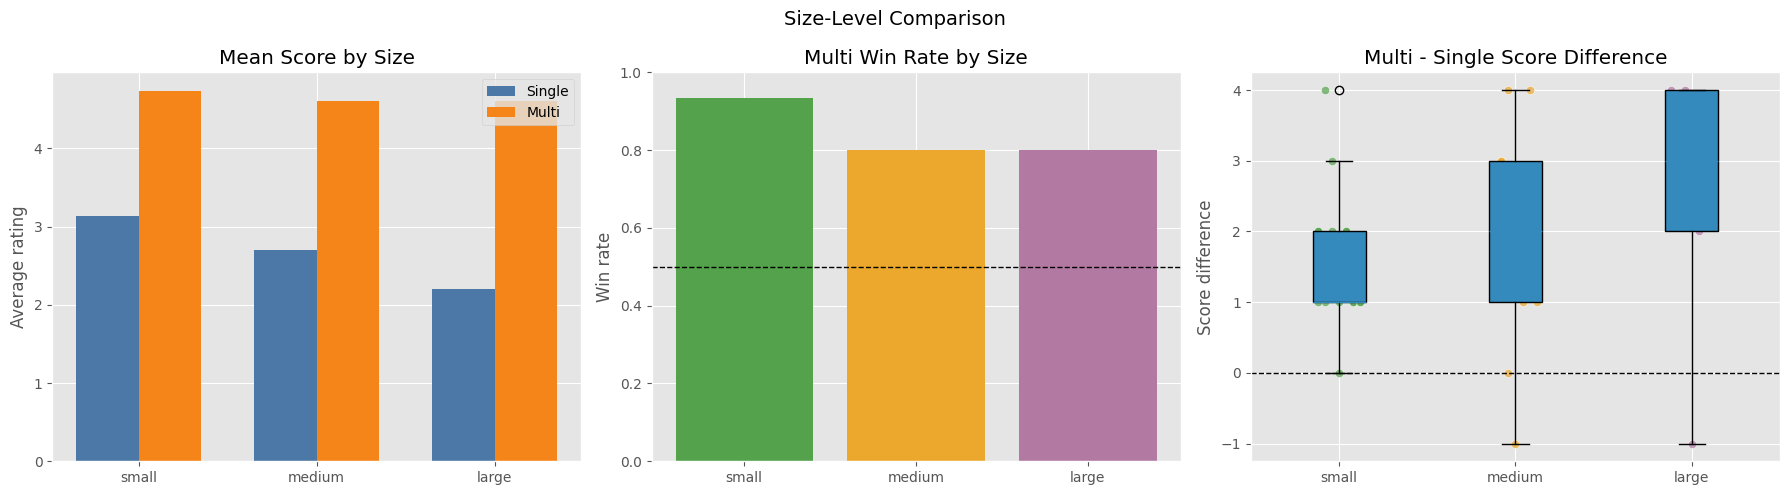

In [7]:
size_plot_df = size_stats_df.set_index("size_label").reindex(SIZE_ORDER).reset_index()
score_diff_by_size = [
    pair_ratings_df.loc[pair_ratings_df["size_label"] == label, "score_diff"].tolist()
    for label in SIZE_ORDER
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_positions = list(range(len(SIZE_ORDER)))
bar_width = 0.35

axes[0].bar(
    [x - bar_width / 2 for x in x_positions],
    size_plot_df["mean_single_score"],
    width=bar_width,
    color=MODE_COLORS["single"],
    label="Single",
)
axes[0].bar(
    [x + bar_width / 2 for x in x_positions],
    size_plot_df["mean_multi_score"],
    width=bar_width,
    color=MODE_COLORS["multi"],
    label="Multi",
)
axes[0].set_xticks(x_positions, SIZE_ORDER)
axes[0].set_title("Mean Score by Size")
axes[0].set_ylabel("Average rating")
axes[0].legend()

axes[1].bar(
    SIZE_ORDER,
    size_plot_df["multi_win_rate"],
    color=[SIZE_COLORS[label] for label in SIZE_ORDER],
)
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].set_ylim(0, 1)
axes[1].set_title("Multi Win Rate by Size")
axes[1].set_ylabel("Win rate")

axes[2].boxplot(score_diff_by_size, tick_labels=SIZE_ORDER, patch_artist=True)
for patch, label in zip(axes[2].artists if hasattr(axes[2], 'artists') else [], SIZE_ORDER):
    patch.set_facecolor(SIZE_COLORS[label])
for idx, label in enumerate(SIZE_ORDER, start=1):
    values = pair_ratings_df.loc[pair_ratings_df["size_label"] == label, "score_diff"].tolist()
    jitter = [idx + ((offset % 7) - 3) / 25 for offset in range(len(values))]
    axes[2].scatter(jitter, values, alpha=0.7, color=SIZE_COLORS[label], edgecolor="white", linewidth=0.5)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Multi - Single Score Difference")
axes[2].set_ylabel("Score difference")

fig.suptitle("Size-Level Comparison", fontsize=14)
fig.tight_layout()
maybe_save_figure(fig, "size_level_comparison")


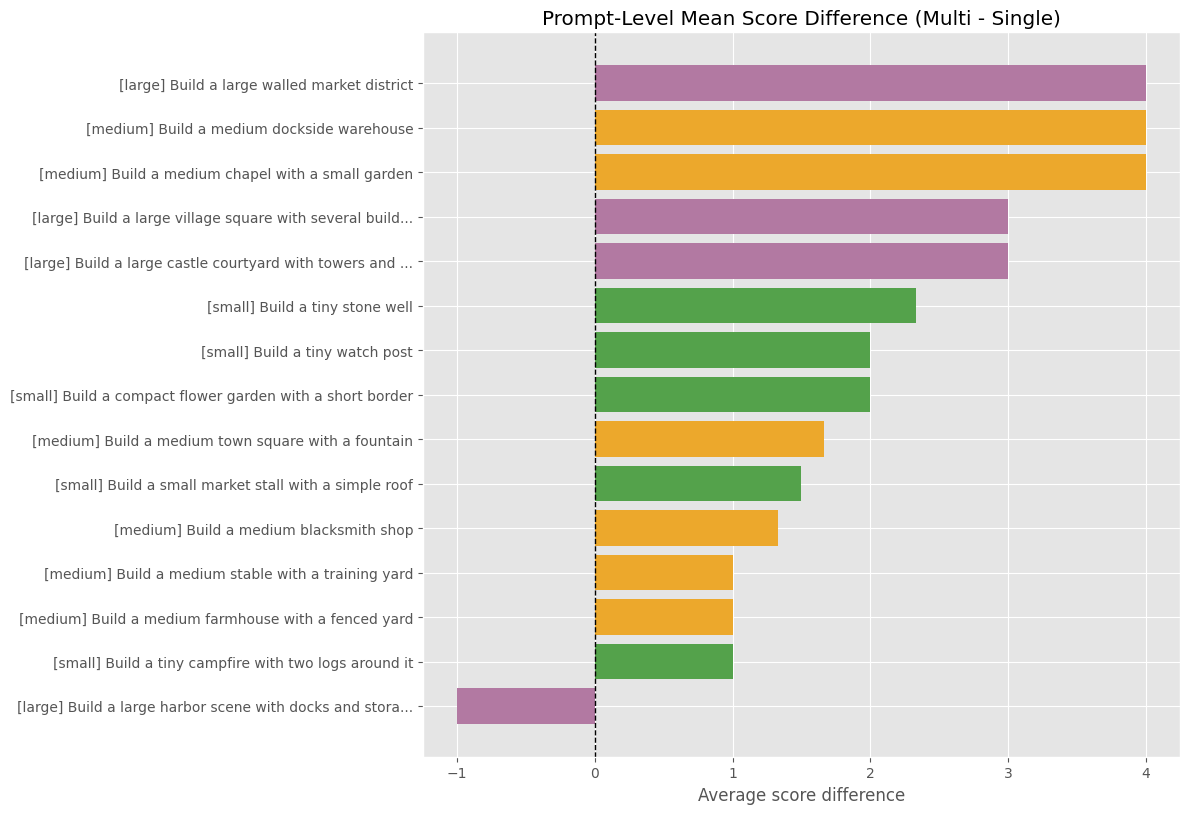

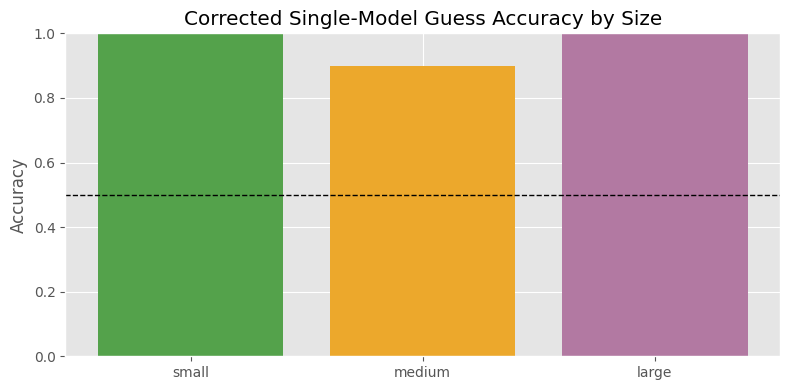

In [8]:
sorted_prompt_stats_df = prompt_stats_df.sort_values("mean_score_diff", ascending=True, kind="stable").reset_index(drop=True)
prompt_labels = [prompt_label(size_label, prompt) for size_label, prompt in zip(sorted_prompt_stats_df["size_label"], sorted_prompt_stats_df["prompt"])]
prompt_colors = [SIZE_COLORS[size_label] for size_label in sorted_prompt_stats_df["size_label"]]

fig, ax = plt.subplots(figsize=(12, max(6, 0.55 * len(sorted_prompt_stats_df))))
ax.barh(prompt_labels, sorted_prompt_stats_df["mean_score_diff"], color=prompt_colors)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Prompt-Level Mean Score Difference (Multi - Single)")
ax.set_xlabel("Average score difference")
fig.tight_layout()
maybe_save_figure(fig, "prompt_level_score_diff")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    SIZE_ORDER,
    size_plot_df["guess_accuracy"],
    color=[SIZE_COLORS[label] for label in SIZE_ORDER],
)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_ylim(0, 1)
ax.set_title("Corrected Single-Model Guess Accuracy by Size")
ax.set_ylabel("Accuracy")
fig.tight_layout()
maybe_save_figure(fig, "guess_accuracy_by_size")


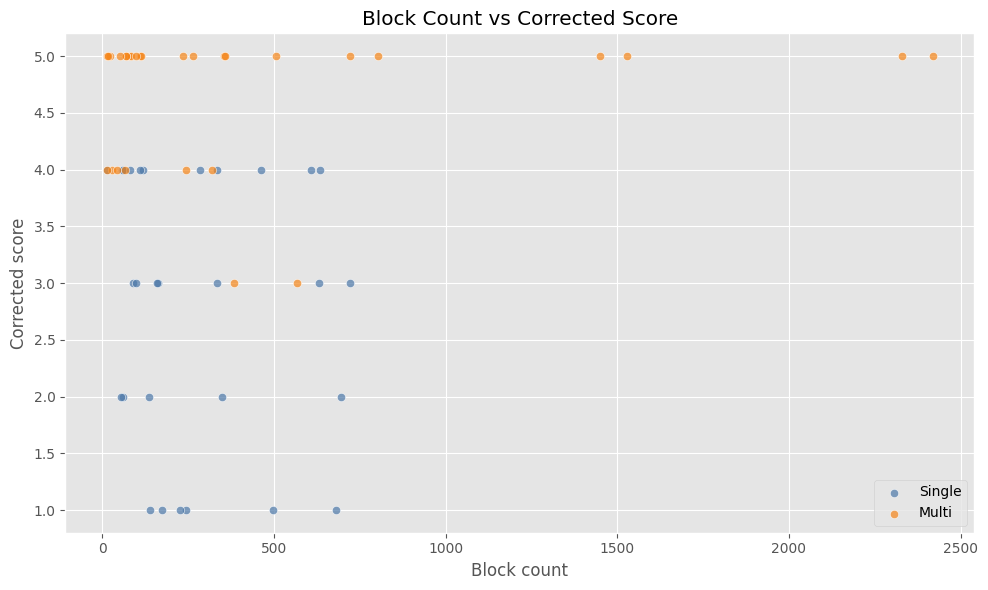

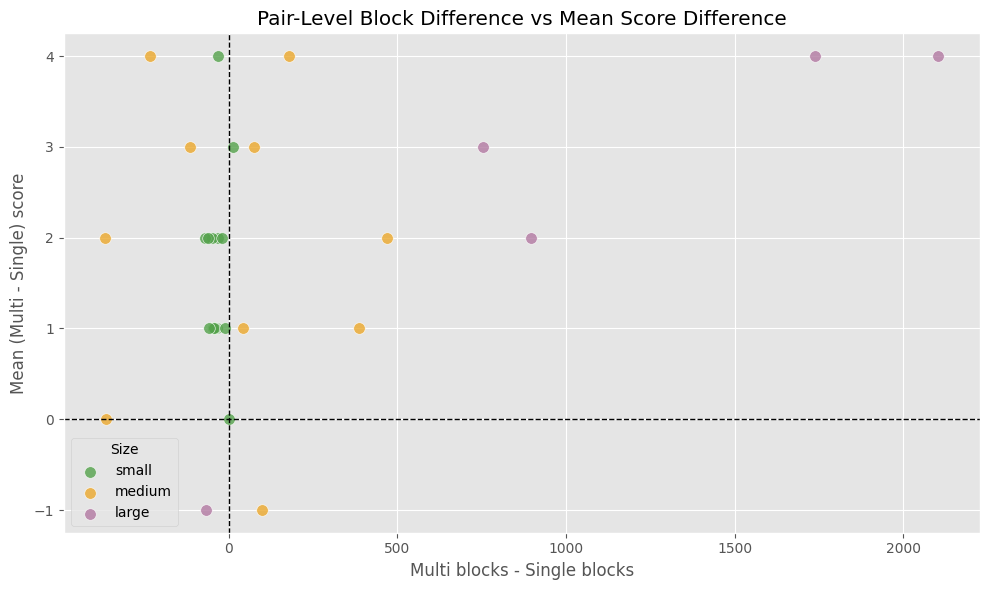

In [9]:
long_scores_df = pd.concat(
    [
        pair_ratings_df[
            ["pair_index", "size_label", "prompt", "rater_name", "single_blocks", "single_score"]
        ]
        .rename(columns={"single_blocks": "block_count", "single_score": "corrected_score"})
        .assign(mode="single"),
        pair_ratings_df[
            ["pair_index", "size_label", "prompt", "rater_name", "multi_blocks", "multi_score"]
        ]
        .rename(columns={"multi_blocks": "block_count", "multi_score": "corrected_score"})
        .assign(mode="multi"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(10, 6))
for mode in ["single", "multi"]:
    subset = long_scores_df.loc[long_scores_df["mode"] == mode]
    ax.scatter(
        subset["block_count"],
        subset["corrected_score"],
        label=mode.title(),
        color=MODE_COLORS[mode],
        alpha=0.7,
        edgecolor="white",
        linewidth=0.5,
    )
ax.set_title("Block Count vs Corrected Score")
ax.set_xlabel("Block count")
ax.set_ylabel("Corrected score")
ax.legend()
fig.tight_layout()
maybe_save_figure(fig, "block_count_vs_score")

pair_delta_df = pair_summary_df.copy()
pair_delta_df["block_diff"] = pair_delta_df["multi_blocks"] - pair_delta_df["single_blocks"]

fig, ax = plt.subplots(figsize=(10, 6))
for size_label in SIZE_ORDER:
    subset = pair_delta_df.loc[pair_delta_df["size_label"] == size_label]
    ax.scatter(
        subset["block_diff"],
        subset["mean_score_diff"],
        label=size_label,
        color=SIZE_COLORS[size_label],
        alpha=0.8,
        edgecolor="white",
        linewidth=0.5,
        s=70,
    )
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Pair-Level Block Difference vs Mean Score Difference")
ax.set_xlabel("Multi blocks - Single blocks")
ax.set_ylabel("Mean (Multi - Single) score")
ax.legend(title="Size")
fig.tight_layout()
maybe_save_figure(fig, "pair_block_diff_vs_score_diff")
